In [1]:
import pandas as pd
import numpy as np
import sys
sys.path.insert(0, '..')
from FAR.utils.measure import Measure, ClusterProcessor, Binning
from FAR.utils.read import LogitToStat, RecoveryData, DataProcessor, Merge
from FAR.utils.predict import predictFeatures
from FAR.utils.utilities import rename_columns, getFARCatalog, remove_little_dogs, rename_data
from FAR.utils.plot import Plotting as pl
from src.torch_utils import load_model, predictions
from sklearn import metrics
import matplotlib.pyplot as plt
import torch
from gwpy.timeseries import TimeSeries
from itertools import product
import math
import pickle
from matplotlib.colors import LinearSegmentedColormap, Normalize
import time
from matplotlib.ticker import ScalarFormatter
import re
import os
np.set_printoptions(precision=6, suppress=True)
#pd.options.mode.chained_assignment = None
pd.set_option('display.float_format', '{:.3f}'.format)


path = '/data/gravwav/lopezm/Projects/GlitchBank/'
path_store = path + 'runs/background/results/'
timeslides_file = 'git_new/computational-aspects-of-machine-learning-project-3/FAR/timeslides_proper.csv'
ifos = ['H1L1', 'H1V1', 'L1V1', 'H1L1V1']
t_searches = [0.561999936580416, 0.673738299086758, 0.6958418315575849, 0.5619617579908676]
merge = Merge(path_store, path + timeslides_file)
darker_colors = ['indigo', 'darkgoldenrod', 'darkcyan', 'dimgray']
#colors = ['mediumorchid','cornflowerblue', 'hotpink', 'mediumseagreen']
colors = ['mediumpurple', 'goldenrod', 'mediumturquoise', 'grey']
t_searches = [0.561999936580416, 0.673738299086758, 0.6958418315575849, 0.5619617579908676]

In [2]:
def computeCounts(tmp, ifo, bins, ycol, p_star):
    
    TPR, yerr, mean_var, xerr = [], [], [], []
    
    for b in range(len(bins) - 1):

        
        if bins[b + 1] != bins[-1]:
            select = tmp[(tmp[ycol] >= bins[b]) & (tmp[ycol] < bins[b + 1])]
        else:
            print(b)
            select = tmp[tmp[ycol] >= bins[-1]]
        
        tp, p, _, _ = Measure.TPR(select, ifo, p_star=p_star)
        if bins[b] >= 13000: print(bins[b], tp/ p, tp, p)
        if p > 0:
            mean_var.append(np.mean(select[ycol]))
            xerr.append(3 * np.std(select[ycol]) / p)
            TPR.append(tp / p)
            #yerr.append(np.sqrt((tp/p)*(1-tp/p) / (p))) Binomial distribution
            yerr.append(np.sqrt(tp)/p)
        else:
            mean_var.append(np.nan)
            xerr.append(np.nan)
            TPR.append(np.nan)
            yerr.append(np.nan)

    return TPR, yerr, mean_var, xerr

def process_column(df, column_name, ifo):
    # Function to convert string to list of floats
    def string_to_float_list(input_string):
        if isinstance(input_string, np.ndarray):
            # Apparently some data does not need 
            # To transform to float... FIXME
            numbers_as_floats = input_string
            return numbers_as_floats
        if type(input_string) is float:
            # For injections sometimes we do not find the 
            # signal
            numbers_as_floats = [np.nan]
            return numbers_as_floats
        else:
            cleaned_string = input_string.strip('[]')
            numbers_as_strings = re.findall(r'[-+]?\d*\.\d+e[+-]?\d+|\d+\.\d+|\d+', cleaned_string)
            numbers_as_floats = [float(number) for number in numbers_as_strings]
            return numbers_as_floats

    # Function to extract the first and second values
    def extract_first_and_second(values):
        first = values[0] if len(values) > 0 else None
        second = values[1] if len(values) > 1 else None
        return first, second

    # Apply the function to convert strings to lists of floats
    df[f'feature_{ifo}_new'] = df[column_name].apply(string_to_float_list)

    # Apply the function and expand the result into two columns
    df[[f'SNR_av_{ifo}', f'Chisq_av_{ifo}']] = df[f'feature_{ifo}_new'].apply(extract_first_and_second).apply(pd.Series)

    # Drop the intermediate column if no longer needed
    df.drop(columns=[f'feature_{ifo}_new'], inplace=True)

    return df

def plotDistandSNR(datas, var, ifos, colors, t_searches, epsilon=1e-4, FAR=0.1, new_stat=False, ptime='HLV'):

    # Define variables
    bins_dist = np.arange(0, 14000, 1000)
    bins_snr = np.concatenate([np.arange(0, 9), np.arange(10, 19, 2), np.arange(20, 55, 5)])
    
    if var == 'SNR': bins, xlabel = bins_snr, 'Injected SNR'
    elif var == 'distance': bins, xlabel = bins_dist, r'Luminosity distance $D_{L}$ (Mpc)'

    vars, TPRs = [], []
    for data, ifo, color, t_search in zip(datas, ifos, colors, t_searches): 

        t_bkg, bkg = merge.mergeTriggers(ifo.replace('1', ""), ptime, new_stat) # FIXME

        if len(ifo) == 4:
            ifo1, ifo2 = ifo[:2], ifo[2:]
            
            if new_stat:
                # bkg = process_column(bkg, 'feature_'+ifo1, ifo1)
                # bkg = process_column(bkg, 'feature_'+ifo2, ifo2)

                stat1 = bkg[f'Pinj_{ifo1}'] / (bkg[f'Chisq_max_{ifo1}'] / bkg[f'SNR_max_{ifo1}']**2)
                stat2 = bkg[f'Pinj_{ifo2}'] / (bkg[f'Chisq_max_{ifo2}'] / bkg[f'SNR_max_{ifo2}']**2)
                bkg['barPinj'] = Measure.harmonic3coinc(stat1, stat2, [0])
                bkg['rank_stat_'+ifo1+ifo2] = bkg['barPinj']

                # data = process_column(data, 'feature_'+ifo1, ifo1)
                # data = process_column(data, 'feature_'+ifo2, ifo2)
                
                stat1 = data[f'Pinj_{ifo1}'] / (data[f'Chisq_max_{ifo1}'] / data[f'SNR_max_{ifo1}']**2)
                stat2 = data[f'Pinj_{ifo2}'] / (data[f'Chisq_max_{ifo2}'] / data[f'SNR_max_{ifo2}']**2)
                data['barPinj'] = Measure.harmonic3coinc(stat1, stat2, [0])
                data['rank_stat_'+ifo1+ifo2] = data['barPinj'] 
            else:
                stat1 = bkg[f'Pinj_{ifo1}']
                stat2 = bkg[f'Pinj_{ifo2}']
                bkg['barPinj'] = Measure.harmonic2coinc(stat1, stat2)
                bkg = Measure.prob2stat(bkg, ifo1+ifo2, col='barPinj')

            data['injSNR' + ifo] = np.sqrt(data['injSNR'+ifo[:2]]**2 + data['injSNR'+ ifo[2:]]**2)
 
        x, y_obs, p_star, ylabel = Measure.getFARandThreshold(bkg, ifo, t_bkg, t_search, FAR=FAR)
        print(ifo, p_star)
        if xlabel == 'Injected SNR': ycol = 'injSNR'+ifo
        else: ycol = 'Distance'

        TPR, yerr, mean_var, xerr = computeCounts(data, ifo, bins, ycol, p_star)

        vars.append(mean_var)
        TPRs.append(TPR)
        plt.plot(mean_var, np.asarray(TPR) + epsilon, label=ifo, c=color, alpha=0.8)
        plt.errorbar(mean_var, TPR, yerr=yerr, xerr=xerr,
                     fmt='o', capsize=2, color=color,
                     markerfacecolor=color, markersize=1, zorder=1)
        
        if xlabel == 'Injected SNR':
            plt.xscale('log')
            # Define the ticks you want on the x-axis
            ticks = [1, 5] + np.arange(10, 50, 10).tolist() + [70]
            plt.xticks(ticks)  # Set the ticks
            
            # Set custom tick labels corresponding to the tick positions
            plt.gca().set_xticklabels([str(tick) for tick in ticks])

            plt.xlim(1)
            
        #plt.yscale('log')
        #plt.yticks([epsilon, 0.01, 0.05, 0.10, 0.20, 0.30, 0.40],
        #           [0, 0.01, 0.05, 0.10, 0.20, 0.30, 0.40])
        #plt.ylim(epsilon, 0.4)
        plt.legend()
        plt.xlabel(xlabel), plt.ylabel('TPR')
        
        
    plt.legend(), plt.ylim((0, 1.05)), plt.grid(True)

    plt.savefig(f'{var}_new_stat.pdf')
    plt.show()
    return vars, TPRs

def plot_inverse_cumulative_histogram(data, bins=10):
    # Compute the histogram
    counts, bin_edges = np.histogram(data, bins=bins)
    
    # Compute the cumulative sum of the counts in reverse order
    inverse_cumulative_counts = np.cumsum(counts[::-1])[::-1]

    return bin_edges, inverse_cumulative_counts

### Injections test

In [ ]:
# path_inj = '/data/gravwav/lopezm/Projects/GlitchBank/runs/injections/'
# inj_hl = predictFeatures(path_inj + 'inj_coinc2_hl.csv', ['h1', 'l1'], 'inj')
# inj_hv = predictFeatures(path_inj + 'inj_coinc2_hv.csv', ['h1', 'v1'], 'inj')
# inj_lv = predictFeatures(path_inj + 'inj_coinc2_lv.csv', ['l1', 'v1'], 'inj')
# inj_hlv = predictFeatures(path_inj + 'inj_coinc3_hlv.csv', ['h1', 'l1', 'v1'], 'inj')

# inj_hl = rename_data('H1L1', inj_hl)
# inj_hv = rename_data('H1V1', inj_hv)
# inj_lv = rename_data('L1V1', inj_lv)
# inj_hlv = rename_data('H1L1V1', inj_hlv)

# inj_hl.to_pickle(path_inj + 'inj_coinc2_pred_hl.csv')
# inj_hv.to_pickle(path_inj + 'inj_coinc2_pred_hv.csv')
# inj_lv.to_pickle(path_inj + 'inj_coinc2_pred_lv.csv')
# inj_hlv.to_pickle(path_inj + 'inj_coinc3_pred_hlv.csv')

In [3]:
path_inj = '/data/gravwav/lopezm/Projects/GlitchBank/runs/injections/'
catalog = pd.read_pickle('/data/gravwav/lopezm/Projects/GlitchBank/runs/known_catalogs.csv')
inj_hl = pd.read_pickle(path_inj + 'inj_coinc2_pred_hl.csv')
inj_hv = pd.read_pickle(path_inj + 'inj_coinc2_pred_hv.csv')
inj_lv = pd.read_pickle(path_inj + 'inj_coinc2_pred_lv.csv')
inj_hlv = pd.read_pickle(path_inj + 'inj_coinc3_pred_hlv.csv')

### FIXME
columns_old = ['Class_V1',
       'Num triggers_V1', 'Cluster ID_V1', 'Cluster time_V1', 'SNR_max_V1',
       'Chisq_max_V1', 'Mass_1_max_V1', 'Mass_2_max_V1']

columns_new = [
       'Num triggers_V1', 'Cluster ID_V1', 'Cluster time_V1', 'SNR_max_V1',
       'Chisq_max_V1', 'Mass_1_max_V1', 'Mass_2_max_V1', 'Some_value']
# Create a dictionary mapping old column names to new column names
rename_dict = dict(zip(columns_old, columns_new))

# Rename the columns in the DataFrame
inj_hlv = inj_hlv.rename(columns=rename_dict)

In [ ]:
with open(path_inj + f'clusters_h1.pkl', 'rb') as f:
    inj_c_h1 = pickle.load(f)
with open(path_inj + f'clusters_l1.pkl', 'rb') as f:
    inj_c_l1 = pickle.load(f)
with open(path_inj + f'clusters_v1.pkl', 'rb') as f:
    inj_c_v1 = pickle.load(f)

### Proper time

In [74]:
ifo = 'H1L1'
ptime = 'HLV'
#for ifo, ptime in zip(['H1L1', 'H1V1', 'L1V1'], ['HL_nV', 'HV_nL', 'LV_nH'])
t_bkg1, bkg1 = merge.mergeTriggers('H1L1', ptime, new_stat=True)
t_bkg2, bkg2 = merge.mergeTriggers('H1V1', ptime, new_stat=True)
t_bkg3, bkg3 = merge.mergeTriggers('L1V1', ptime, new_stat=True)
x1, y_obs1, _, _ = Measure.getFARandThreshold(bkg1, 'H1L1',
                                              t_bkg1, t_search, maximum=350, FAR=0.1)
x2, y_obs2, _, _ = Measure.getFARandThreshold(bkg2, 'H1V1',
                                              t_bkg2, t_search, maximum=350, FAR=0.1)
x3, y_obs3, _, _ = Measure.getFARandThreshold(bkg3, 'L1V1',
                                              t_bkg3, t_search, maximum=350, FAR=0.1)


ptime HLV 1000
1792 1792
ptime HLV 1000
1792 1792
ptime HLV 1000
1792 1792


In [94]:
bin_array = np.arange(1, 10)[::-1].tolist() + (np.arange(1, 10)/10)[::-1].tolist() + (np.arange(1, 10)/100)[::-1].tolist() + (np.arange(1, 10)/1000)[::-1].tolist()
bin_array

[9,
 8,
 7,
 6,
 5,
 4,
 3,
 2,
 1,
 0.9,
 0.8,
 0.7,
 0.6,
 0.5,
 0.4,
 0.3,
 0.2,
 0.1,
 0.09,
 0.08,
 0.07,
 0.06,
 0.05,
 0.04,
 0.03,
 0.02,
 0.01,
 0.009,
 0.008,
 0.007,
 0.006,
 0.005,
 0.004,
 0.003,
 0.002,
 0.001]

In [98]:
np.count_nonzero(y_obs1 == 0)


3612

In [108]:
bin_array = np.arange(1, 10)[::-1].tolist() + (np.arange(1, 10)/10)[::-1].tolist() + (np.arange(1, 10)/100)[::-1].tolist() + (np.arange(1, 10)/1000)[::-1].tolist() + [0.0001]
Ns = []
for i in range(len(bin_array)):
    N = np.sum(np.hstack([ y_obs1[y_obs1 != 0],
                          y_obs2[y_obs2 != 0], 
                          y_obs3[y_obs3 != 0]])[:, None] <= bin_array[i], axis=0)
    Ns.append(N)

In [110]:
min(y_obs2[y_obs2 != 0])

0.001

In [109]:
np.sort(Ns)

array([[79028],
       [78791],
       [78285],
       [77389],
       [76401],
       [75095],
       [73200],
       [70662],
       [67475],
       [67123],
       [66684],
       [66301],
       [65837],
       [65287],
       [64557],
       [63631],
       [62100],
       [59141],
       [58750],
       [58043],
       [57123],
       [56068],
       [54838],
       [53207],
       [51370],
       [49213],
       [42072],
       [41472],
       [37710],
       [36026],
       [33507],
       [31431],
       [26985],
       [20256],
       [10762],
       [ 3646],
       [    0]])

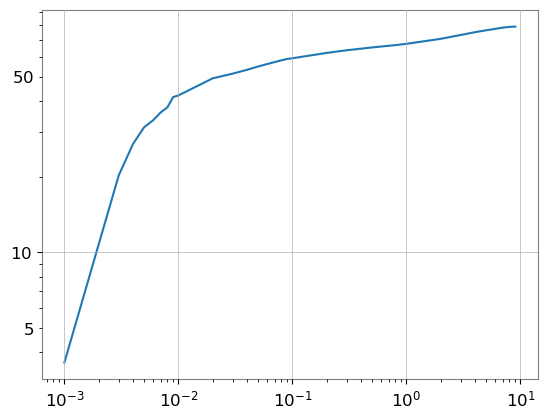

In [105]:
plt.plot(bin_array, np.sort(Ns)/1000)
plt.xscale('log')
plt.yscale('log')

In [47]:
import numpy as np

def calculate_combined_far_multiple_arrays(far_values_list, Tb, far_star):
    """
    Calculate the combined False Alarm Rate (FAR_combined) based on the provided formula
    across multiple arrays of FAR values.
    
    Parameters:
    - far_values_list: List of arrays, where each array contains FAR values from different analyses or sources.
    - Tb: Total slide duration (T_b) for all slides performed.
    - far_star: The FAR* threshold value for which the combined FAR is calculated.
    
    Returns:
    - FAR_combined: The calculated combined False Alarm Rate.
    """
    # Initialize total count N_tot
    N_tot = 0
    
    # Loop through each array of FAR values
    for far_values in far_values_list:
        # Count the number of FAR values in this array that are less than or equal to FAR*
        N_tot += np.sum(far_values <= far_star)
    
    # Calculate FAR_combined
    FAR_combined = N_tot / Tb
    print(N_tot, Tb)
    
    return FAR_combined

# Example usage:
# Example list of uncombined FAR arrays from different analyses
far_values1 = y_obs1.copy()
far_values2 = y_obs2.copy()

# Combine them into a list
far_values_list = [far_values1, far_values2]

Tb = 1000.0  # Example total slide duration in seconds
far_star = 0.001  # Example FAR* threshold

# Calculate the combined FAR across all arrays
far_combined = calculate_combined_far_multiple_arrays(far_values_list, Tb, far_star)

print(f"Combined False Alarm Rate (FAR_combined): {far_combined}")


22777 1000.0
Combined False Alarm Rate (FAR_combined): 22.777


#### Some plottting

In [ ]:
new_stat=True
for ifo in ifos:
    t_bkg, bkg = merge.mergeTriggers(ifo, 'HLV', new_stat=new_stat)
    print(ifo,len( bkg))

In [ ]:

fig, axs = plt.subplots(1, 1, dpi=120)

ptime = 'HLV'
for c, ifo, t_search,  inj in zip(colors, ifos, t_searches, [inj_hl, inj_hv, inj_lv, inj_hlv]):
    new_stat=False
    dt = np.concatenate([np.zeros(1), np.arange(0.01, 0.9, 0.01),
                     np.asarray([0.9, 0.99, 0.999, 0.9999,
                                 0.99999, 0.999999,0.9999999,
                                 0.99999999, 0.999999999])])
    
    tprs, fprs = [], []
    t_bkg, bkg = merge.mergeTriggers(ifo, ptime)
    x, y_obs, _, _ = Measure.getFARandThreshold(bkg, ifo, t_bkg, t_search, FAR=0.1)
    pos, neg = inj.copy(), bkg.copy()
    

    # To test in tripple time
    if len(ifo) == 4:
        ifo1, ifo2 = ifo[:2], ifo[2:]

        stat1, stat2 = pos['Pinj_'+ifo1], pos['Pinj_'+ifo2]
        pos['barPinj'] = Measure.harmonic3coinc(stat1, stat2, [0])
        pos['rank_stat_'+ifo1+ifo2] = pos['barPinj'] 

        stat1, stat2 = neg['Pinj_'+ifo1], neg['Pinj_'+ifo2]
        neg['barPinj'] = Measure.harmonic3coinc(stat1, stat2, [0])
        neg['rank_stat_'+ifo1+ifo2] = neg['barPinj'] 
    
        
    for d in dt:
        p_star = - np.log(1 - d + 1e-20)
        # We only consider post GstLAL
        tp, p, _, _ = Measure.TPR(pos, ifo, p_star=p_star)
        tpr = tp /p * 100
        fpr = Measure.FPR(neg, ifo, p_star=p_star)
        tprs.append(tpr)
        fprs.append(fpr)

    correction = (100 - max(fprs))*max(tprs)
    auc = metrics.auc(fprs, tprs) + correction
    print(ifo, auc)
    axs.plot(fprs, tprs, c=c, linestyle='--')
    axs.set_xlabel('FPR'), axs.set_ylabel('TPR')

    new_stat=True
    dt = np.concatenate([np.arange(0, 20, 5), np.arange(20, 190, 10),
                         np.arange(190, 200, 10)])
    
    
    tprs, fprs = [], []
    t_bkg, bkg = merge.mergeTriggers(ifo, ptime, new_stat=new_stat) # FIXME
    x, y_obs, _, _ = Measure.getFARandThreshold(bkg, ifo, t_bkg, t_search, FAR=0.1)
    pos, neg = inj.copy(), bkg.copy()
    
    if new_stat:
        if len(ifo) == 4:
            stat1 = pos[f'Pinj_{ifo1}'] / (pos[f'Chisq_max_{ifo1}'] / pos[f'SNR_max_{ifo1}']**2)
            stat2 = pos[f'Pinj_{ifo2}'] / (pos[f'Chisq_max_{ifo2}'] / pos[f'SNR_max_{ifo2}']**2)
            pos['barPinj'] = Measure.harmonic3coinc(stat1, stat2, [0])
            pos['rank_stat_'+ifo1+ifo2] = pos['barPinj'] 

            stat1 = neg[f'Pinj_{ifo1}'] / (neg[f'Chisq_max_{ifo1}'] / neg[f'SNR_max_{ifo1}']**2)
            stat2 = neg[f'Pinj_{ifo2}'] / (neg[f'Chisq_max_{ifo2}'] / neg[f'SNR_max_{ifo2}']**2)
            neg['barPinj'] = Measure.harmonic3coinc(stat1, stat2, [0])
            neg['rank_stat_'+ifo1+ifo2] = neg['barPinj']
        if len(ifo) == 6:
            stat1 = pos[f'Pinj_H1'] / (pos[f'Chisq_max_H1'] / pos[f'SNR_max_H1']**2)
            stat2 = pos[f'Pinj_L1'] / (pos[f'Chisq_max_L1'] / pos[f'SNR_max_L1']**2)
            stat3 = pos[f'Pinj_V1'] / (pos[f'Chisq_max_V1'] / pos[f'SNR_max_V1']**2)
            pos['barPinj'] = Measure.harmonic3coinc(stat1, stat2, stat3)
            pos['rank_stat_H1L1V1'] = pos['barPinj']

            stat1 = neg[f'Pinj_H1'] / (neg[f'Chisq_max_H1'] / neg[f'SNR_max_H1']**2)
            stat2 = neg[f'Pinj_L1'] / (neg[f'Chisq_max_L1'] / neg[f'SNR_max_L1']**2)
            stat3 = neg[f'Pinj_V1'] / (neg[f'Chisq_max_V1'] / neg[f'SNR_max_V1']**2)
            neg['barPinj'] = Measure.harmonic3coinc(stat1, stat2, stat3)
            neg['rank_stat_H1L1V1'] = neg['barPinj']
            
    
    for d in dt:
        p_star = d
        # We only consider post GstLAL
        tp, p, _, _ = Measure.TPR(pos, ifo, p_star=p_star)
        tpr = tp /p * 100
        fpr = Measure.FPR(neg, ifo, p_star=p_star)
        tprs.append(tpr)
        fprs.append(fpr)

    correction = (100 - max(fprs))*max(tprs)
    auc = metrics.auc(fprs, tprs) + correction
    print(ifo, auc)
    axs.plot(fprs, tprs, c=c, label=ifo)
    axs.set_xlabel('FPR'), axs.set_ylabel('TPR'), axs.legend()


#plt.text(70, 90, r'$- \log{(1-\bar{P}_{inj})}$', bbox=dict(facecolor='white', edgecolor='grey', boxstyle='round,pad=0.5'))
plt.tight_layout()
plt.savefig('roc_new_old_stat_HLV_ptime.pdf')

In [ ]:
snrs, tpr_snrs = plotDistandSNR([inj_hl, inj_hv, inj_lv], 'SNR', 
                                ifos[:-1], colors[:-1], t_searches[:-1])
dists, tpr_dists = plotDistandSNR([inj_hl, inj_hv, inj_lv], 'distance',
                                  ifos[:-1], colors[:-1], t_searches[:-1])

In [ ]:
snrs, tpr_snrs = plotDistandSNR([inj_hl, inj_hv, inj_lv, inj_hlv], 'SNR', 
                                ifos, colors, t_searches, new_stat=True)
dists, tpr_dists = plotDistandSNR([inj_hl, inj_hv, inj_lv, inj_hlv], 'distance',
                                  ifos, colors, t_searches, new_stat=True)

ptime HLV 1000
1792 1792
ptime HLV 1000
1792 1792
ptime HLV 1000
1792 1792
ptime HLV 1000
1792 1792


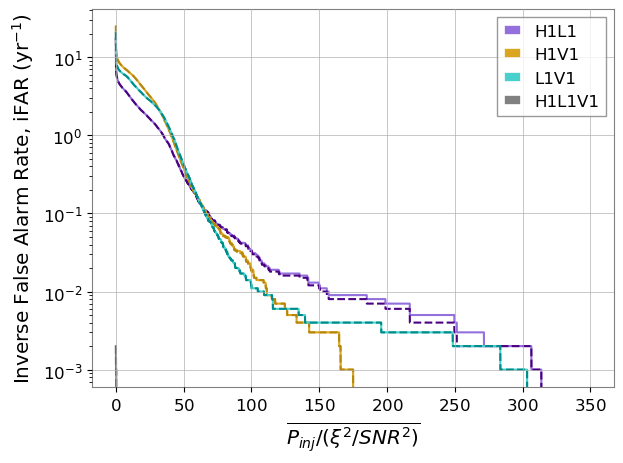

In [36]:
ptime = 'HLV'
for ifo, color, dark_color, t_search in zip(ifos, colors, darker_colors, t_searches):

    t_bkg, bkg = merge.mergeTriggers(ifo, ptime, new_stat=True) # FIXME
    bkg_ = remove_little_dogs(catalog, bkg, ifo, offset = 1)

    x1, y_obs1, _, _ = Measure.getFARandThreshold(bkg, ifo, t_bkg, t_search, maximum=350, FAR=0.1)
    x2, y_obs2, _, _ = Measure.getFARandThreshold(bkg_, ifo, t_bkg, t_search, maximum=350, FAR=0.1)
    
    # Plot the inverse cumulative histogram
    plt.plot(x1, y_obs1, color=color, label=ifo)
    plt.plot(x2, y_obs2, alpha=1, linestyle='--', color=dark_color)
    plt.xlabel(r'$\overline{P_{inj}/(\xi^2/SNR^2)}$')
    plt.ylabel('Inverse False Alarm Rate, iFAR (yr$^{-1}$)')
    plt.yscale('log')
    plt.legend()
    plt.tight_layout()
    plt.savefig('ifar_new_stat.pdf')

0   0.000
1   0.245
Name: rank_stat_H1L1V1, dtype: float64

In [ ]:
ptime = 'HLV'
for ifo, color, dark_color, t_search in zip(ifos, colors, darker_colors, t_searches):

    t_bkg, bkg = merge.mergeTriggers(ifo, ptime, new_stat=True) # FIXME
    bkg_ = remove_little_dogs(catalog, bkg, ifo, offset = 1)
    print(ifo, len(bkg), len(bkg_), t_bkg)

    b1, i1 = plot_inverse_cumulative_histogram(bkg['rank_stat_'+ifo], bins=1000)
    b2, i2 = plot_inverse_cumulative_histogram(bkg_['rank_stat_'+ifo], bins=1000)
    
    # Plot the inverse cumulative histogram
    plt.plot(b1[:-1], i1, color=color, label=ifo)
    plt.plot(b2[:-1], i2, alpha=1, linestyle='--', color=dark_color)
    plt.xlabel(r'$\overline{P_{inj}/(\xi^2/SNR^2)}$')
    plt.ylabel('Inverse cumulative time shifts')
    plt.yscale('log')
    plt.legend()
    plt.tight_layout()
    #plt.savefig('inv_cum_new_stat.pdf')

In [ ]:
ifo = 'H1L1'
ifo1, ifo2 = ifo[:2], ifo[2:]
t_bkg, bkg = merge.mergeTriggers(ifo, new_stat=True)
bkg = bkg.sort_values(by='rank_stat_'+ifo, ascending=False)
with open('/data/gravwav/lopezm/Projects/GlitchBank/runs/zero_lag/' + f'clusters_unknown_{ifo1.lower()}_reduced.pkl', 'rb') as f:
    cluster1 = pickle.load(f)
with open('/data/gravwav/lopezm/Projects/GlitchBank/runs/zero_lag/' + f'clusters_unknown_{ifo2.lower()}_reduced.pkl', 'rb') as f:
    cluster2 = pickle.load(f)

In [ ]:
bkg[['Pinj_H1', 'Pinj_L1', 
     'SNR_max_H1', 'SNR_max_L1', 'Chisq_max_H1', 'Chisq_max_L1',
     'rank_stat_'+ifo1+ifo2]].head(5)

In [ ]:
display(bkg.iloc[i][['Pinj_H1', 'Pinj_L1', 'SNR_max_H1', 'SNR_max_L1', 'Chisq_max_H1', 'Chisq_max_L1']])

In [ ]:

for i in range(5):
    print(bkg.iloc[i]['Cluster time_'+ifo1], bkg.iloc[i]['Cluster time_'+ifo2])
    print(bkg.iloc[i]['Cluster time old_'+ifo1], bkg.iloc[i]['Cluster time old_'+ifo2])
    pl.plotSpect2coinc(ifo1, ifo2, bkg.iloc[i]['Cluster time old_'+ifo1],
                    bkg.iloc[i]['Cluster time old_'+ifo2])
    display(bkg.iloc[i][['Pinj_H1', 'Pinj_L1', 'SNR_max_H1', 'SNR_max_L1', 'Chisq_max_H1', 'Chisq_max_L1']])
    plt.scatter(cluster1[bkg.iloc[i]['Cluster idx_'+ifo1]]['Mass_1'],
                cluster1[bkg.iloc[i]['Cluster idx_'+ifo1]]['Mass_2'], s=1, label=ifo1)
    plt.scatter(cluster2[bkg.iloc[i]['Cluster idx_'+ifo2]]['Mass_1'], 
                cluster2[bkg.iloc[i]['Cluster idx_'+ifo2]]['Mass_2'], s=1, alpha=0.5, label=ifo2)
    plt.scatter(bkg.iloc[i]['Mass_1_max_'+ifo1], bkg.iloc[i]['Mass_2_max_'+ifo1],
                s=10, marker='*', alpha=0.5, label=ifo2, c='cornflowerblue')
    plt.scatter(bkg.iloc[i]['Mass_1_max_'+ifo2], bkg.iloc[i]['Mass_2_max_'+ifo2],
                s=10, marker='*', alpha=0.5, label=ifo2, c='darkorange')

    plt.xlabel('$m_1$'), plt.ylabel('$m_2$')
    plt.xscale('log'), plt.yscale('log')
    plt.legend()
    plt.show()

In [ ]:
for i in range(10):
    tmp1 = inj_c_h1[i]
    tmp2 = inj_c_l1[i]
    # display(tmp1)
    # display(tmp2)
    print(np.unique(tmp1['Cluster time'])[0], np.unique(tmp2['Cluster time'])[0], np.unique(tmp1['Cluster time'])[0] - np.unique(tmp2['Cluster time'])[0])
    plt.scatter(tmp1['Mass_1'], tmp1['Mass_2'], s=1)
    plt.scatter(tmp2['Mass_1'], tmp2['Mass_2'], alpha=0.5, s=1)
    plt.xscale('log'), plt.yscale('log')
    plt.grid(False)
    plt.show()

### Zero lag test

In [ ]:
%%time
path_inj = '/data/gravwav/lopezm/Projects/GlitchBank/runs/zero_lag/'

u_h1 = predictFeatures(path_inj + 'unknown_h1_reduced.csv', ['h1'], 'zero_lag')
u_l1 = predictFeatures(path_inj + 'unknown_l1_reduced.csv', ['l1'], 'zero_lag')
u_v1 = predictFeatures(path_inj + 'unknown_v1_reduced.csv', ['v1'], 'zero_lag')

In [ ]:
path_store_pred = '/data/gravwav/lopezm/Projects/GlitchBank/computational-aspects-of-machine-learning-project-3/output_new/tw0.05/predictions/'
u_h1.rename(columns=lambda col: rename_columns(col, '_h1', ''), inplace=True)
u_l1.rename(columns=lambda col: rename_columns(col, '_l1', ''), inplace=True)
u_v1.rename(columns=lambda col: rename_columns(col, '_v1', ''), inplace=True)

u_h1.to_pickle(path_store_pred + 'pred_logs_unknown_eqmatch_reduced_H1.csv')
u_l1.to_pickle(path_store_pred + 'pred_logs_unknown_eqmatch_reduced_L1.csv')
u_v1.to_pickle(path_store_pred + 'pred_logs_unknown_eqmatch_reduced_V1.csv')

### Time slides test

In [ ]:
path_store = '/data/gravwav/lopezm/Projects/GlitchBank/runs/zero_lag/'
path = '/data/gravwav/lopezm/Projects/GlitchBank/'
dp = DataProcessor(path + 'computational-aspects-of-machine-learning-project-3/output_new/tw0.05/predictions/', path + 'runs/zero_lag/', path + 'runs/injections')

start_time = time.time()
u_h1, uc_h1 = dp.LoadZeroLag('h1', reset=True)
u_l1, uc_l1 = dp.LoadZeroLag('l1', reset=True)
u_v1, uc_v1 = dp.LoadZeroLag('v1', reset=True)
end_time = time.time()

In [ ]:
def coincTriggers3(x, data_x, data_y, data_z, cluster_x, cluster_y, cluster_z, shift1=0, shift2=0, shift3=0, window=1):
        """
        Find coincident triggers between three data sets within a time window.

        Parameters:
        x (int): Index of the trigger in data_x.
        data_x (pd.DataFrame): DataFrame containing the first set of data.
        data_y (pd.DataFrame): DataFrame containing the second set of data.
        data_z (pd.DataFrame): DataFrame containing the third set of data.
        cluster_x (dict): Dictionary containing clusters for data_x.
        cluster_y (dict): Dictionary containing clusters for data_y.
        cluster_z (dict): Dictionary containing clusters for data_z.
        shift1 (float): Time shift for the first cluster.
        shift2 (float): Time shift for the second cluster.
        shift3 (float): Time shift for the third cluster.
        window (float): Time window for finding coincident triggers.

        Returns:
        tuple: Index x, index y, index z, and delta_t values if conditions are met; otherwise, returns None values.
        """
       
        # Directly access the value instead of using iloc
        cluster_time_x = data_x.at[x, 'Cluster time']

        # Vectorized condition check
        mask = (data_y['Cluster time'] >= cluster_time_x - window) & (data_y['Cluster time'] <= cluster_time_x + window)
        tmp_y = data_y[mask]

        mask = (data_z['Cluster time'] >= cluster_time_x - window) & (data_z['Cluster time'] <= cluster_time_x + window)
        tmp_z = data_z[mask]

        if (tmp_y.empty) or (tmp_z.empty):
            return x, None, None, None, None, None

        for i, j in product(range(len(tmp_y)), range(len(tmp_z))):
            y = tmp_y.index[i]
            z = tmp_z.index[j]
            #tx, ty, tz = cluster_time_x, tmp_y['Cluster time'].iloc[i], tmp_z['Cluster time'].iloc[j]
            #print(tx, ty, tx)
            cluster1, cluster2, cluster3 = cluster_x[x], cluster_y[y], cluster_z[z]
    
            # Check the length conditions
            if len(cluster1) < 10 or len(cluster2) < 10 or len(cluster3) < 10:
                return x, None, None, None, None, None

            tmp = mergeClusters3(cluster1, cluster2, cluster3, shift2=shift2, shift3=shift3)
            
            delta_t1, delta_t2, delta_t3 = tmp['Delta t_hl'].mean(), tmp['Delta t_hv'].mean(), tmp['Delta t_lv'].mean()
            if len(tmp) > 0:
                print(i, delta_t1, delta_t2, delta_t3)
            if (delta_t1 <= 0.015) and (delta_t2 <= 0.032) and (delta_t3 <= 0.031):
                # print(delta_t1, delta_t2, delta_t3)
                return x, y, z, delta_t1, delta_t2, delta_t3
    
        return x, None, None, None, None, None

def coincTriggers3(x, data_x, data_y, data_z, cluster_x, cluster_y, cluster_z, shift1=0, shift2=0, shift3=0, window=1):
    cluster_time_x = data_x.at[x, 'Cluster time']
    
    if data_x.at[x, 'Num triggers'] < 10:
        return x, None, None, None, None, None

    mask_y = (data_y['Cluster time'] >= cluster_time_x - window) & (data_y['Cluster time'] <= cluster_time_x + window)
    tmp_y = data_y[mask_y]

    mask_z = (data_z['Cluster time'] >= cluster_time_x - window) & (data_z['Cluster time'] <= cluster_time_x + window)
    tmp_z = data_z[mask_z]

    if tmp_y.empty or tmp_z.empty:
        return x, None, None, None, None, None
    
    tmp_y.reset_index(inplace=True)
    tmp_z.reset_index(inplace=True)

    results = []
    cluster1 = cluster_x[x]
    for _, row_y in tmp_y.iterrows():
        for _, row_z in tmp_z.iterrows():
            y = row_y['index']
            z = row_z['index']
            ty = row_y['Cluster time']
            tz = row_z['Cluster time']
            cluster2 = cluster_y[y]
            cluster3 = cluster_z[z]

            if len(cluster2) < 10 or len(cluster3) < 10:
                continue
            print(i, len(cluster1), len(cluster2), len(cluster3))

            tmp = mergeClusters3(cluster1, cluster2, cluster3, shift2=shift2, shift3=shift3)
            
            if len(tmp) > 0:
                delta_t1, delta_t2, delta_t3 = tmp['Delta t_hl'].mean(), tmp['Delta t_hv'].mean(), tmp['Delta t_lv'].mean()
                if (delta_t1 <= 0.015) and (delta_t2 <= 0.032) and (delta_t3 <= 0.031):
                    results.append((x, y, z, delta_t1, delta_t2, delta_t3))
    
    if results:
        return results[0]
    else:
        return x, None, None, None, None, None


def mergeClusters(cluster1, cluster2, suffixes, label, shift1=0, shift2=0):
        tmp = pd.merge(cluster1.drop_duplicates(subset=['Template ID']),
                       cluster2.drop_duplicates(subset=['Template ID']),
                       on=['Template ID'], how='inner', suffixes=suffixes)
        # if len(tmp) > 0:
        #     print('cluster', t1, t2, suffixes)
        #     print('trigger', shift1, shift2, (tmp['Trigger time' + suffixes[0]].values[0]+ shift1) - (tmp['Trigger time' + suffixes[1]].values[0]+ shift2))
        tmp[label] = np.abs((tmp['Trigger time' + suffixes[0]] + shift1)  - (tmp['Trigger time' + suffixes[1]] + shift2))
        #if tmp[label].mean() < 0.35:
        #    print(tmp[label].mean(), suffixes)
        return tmp

# def mergeClusters3(cluster1, cluster2, cluster3, shift2=0, shift3=0):
#         tmp = pd.merge(cluster1.drop_duplicates(subset=['Template ID']),
#                        cluster2.drop_duplicates(subset=['Template ID']),
#                        on=['Template ID'], how='inner', suffixes=['_h1', '_l1'])
#         if len(tmp) > 0: print('hl', len(tmp))
#         # This is a hack for '_v1' suffixes
#         cluster3 = cluster3.rename(columns={col: col + '_v1' if col != 'Template ID' else col for col in cluster3.columns})
#         tmp = pd.merge(tmp.drop_duplicates(subset=['Template ID']),
#                        cluster3.drop_duplicates(subset=['Template ID']),
#                        on=['Template ID'], how='inner', suffixes=['', '_v1'])
    
#         # We shift the clusters in time
#         tmp['Trigger time_l1'] = tmp['Trigger time_l1'] + shift2
#         tmp['Trigger time_v1'] = tmp['Trigger time_v1'] + shift3

#         # And calculate delta time
#         tmp['Delta t_hl'] = np.abs(tmp['Trigger time_h1'] - tmp['Trigger time_l1'])
#         tmp['Delta t_hv'] = np.abs(tmp['Trigger time_h1'] - tmp['Trigger time_v1'])
#         tmp['Delta t_lv'] = np.abs(tmp['Trigger time_l1'] - tmp['Trigger time_v1'])
#         # if len(tmp) > 0:
#         #     print(shift2, shift3)
#         #     print(tmp[['Trigger time_h1', 'Trigger time_l1', 'Trigger time_v1']])
#         #     print(tmp[['Delta t_hl', 'Delta t_hv', 'Delta t_lv']])
#         #     print(' ')
#         return tmp

def mergeClusters3(cluster1, cluster2, cluster3, shift2=0, shift3=0):
    # Drop duplicates before merging
    cluster1_unique = cluster1.drop_duplicates(subset=['Template ID'])
    cluster2_unique = cluster2.drop_duplicates(subset=['Template ID'])
    cluster3_unique = cluster3.drop_duplicates(subset=['Template ID'])
    # Merge cluster1 and cluster2
    tmp = pd.merge(cluster1_unique, cluster2_unique, on='Template ID', how='inner', suffixes=['_h1', '_l1'])
    print(cluster1_unique['Template ID'].values,cluster2_unique['Template ID'].values)
    print(np.intersect1d(cluster1_unique['Template ID'].values, cluster2_unique['Template ID'].values))
    if tmp.empty:
        return tmp

    # Rename columns in cluster3
    cluster3_unique = cluster3_unique.rename(columns={col: col + '_v1' if col != 'Template ID' else col for col in cluster3_unique.columns})

    # Merge with cluster3
    tmp = pd.merge(tmp, cluster3_unique, on='Template ID', how='inner')

    if tmp.empty:
        return tmp

    # Shift the clusters in time
    tmp['Trigger time_l1'] += shift2
    tmp['Trigger time_v1'] += shift3

    # Calculate delta time
    tmp['Delta t_hl'] = np.abs(tmp['Trigger time_h1'] - tmp['Trigger time_l1'])
    tmp['Delta t_hv'] = np.abs(tmp['Trigger time_h1'] - tmp['Trigger time_v1'])
    tmp['Delta t_lv'] = np.abs(tmp['Trigger time_l1'] - tmp['Trigger time_v1'])

    return tmp


In [ ]:
sl, sv = 0, 0
u_l1_ = dp.shiftedDataSet(u_l1, window=6)
u_v1_ = dp.shiftedDataSet(u_v1, window=12)
cp = ClusterProcessor()

In [ ]:
i = 1
start = time.time()
h4, l4, v4, t13, t23, t33 = coincTriggers3(i, u_h1, u_l1,
                                                  u_v1, uc_h1,
                                                  uc_l1, uc_v1, shift1=0, shift2=sl, shift3=sv, window=0.5)
print(h4, l4, v4, t13, t23, t33)
end = time.time()
print(end - start)

In [ ]:
H4, L4, V4, T13, T23, T33 = [], [], [], [], [], []
for i in range(len(u_h1)):
    #if i % 1000 == 0: print(i)
    print(i)
    start = time.time()
    h4, l4, v4, t13, t23, t33 = coincTriggers3(i, u_h1, u_l1,
                                                      u_v1, uc_h1,
                                                      uc_l1, uc_v1, shift1=0, shift2=sl, shift3=sv, window=0.5)
    end = time.time()
    #print(end - start)
    H4.append(h4); L4.append(l4); T13.append(t13)

### Zero lag coincidence

In [ ]:
ifo = 'H1L1'
path_zero_lag = '/data/gravwav/lopezm/Projects/GlitchBank/runs/zero_lag/'
catalog = pd.read_pickle('/data/gravwav/lopezm/Projects/GlitchBank/runs/known_catalogs.csv')

for ifo in ifos[:-1]:
    t_bkg, bkg = merge.mergeTriggers(ifo) 
    
    file = f'triggers{ifo.replace("1", "")}_zero_lag_eq_match.csv'
    tmp = pd.read_csv(path_zero_lag+file)
    tmp = tmp.sort_values(by='rank_stat_'+ifo, ascending=False)
    print(len(bkg), len(tmp))

In [ ]:
!ls /data/gravwav/lopezm/Projects/GlitchBank/runs/background/results/ -l -t | head -10

In [ ]:
for ifo in ifos[:-1]:
    print(ifo)
    file = f'triggers{ifo.replace("1", "")}_zero_lag_eq_match.csv'
    tmp = pd.read_csv(path_zero_lag+file)
    
    path_time_slides = '/data/gravwav/lopezm/Projects/GlitchBank/runs/background/results/'
    file_ = f'triggers{ifo.replace("1", "")}_run_eq_match1_zero_background.csv'
    tmp_ = pd.read_csv(path_time_slides+file_)
    if ifo == 'H1V1':
        print(ifo, len(tmp), len(tmp_),
          (tmp['Cluster time old_'+ifo[:2]][1:].values == tmp_['Cluster time old_'+ifo[:2]].values).sum())
    else:
        print(ifo, len(tmp), len(tmp_),
          (tmp['Cluster time old_'+ifo[:2]].values == tmp_['Cluster time old_'+ifo[:2]].values).sum())


In [ ]:
print(len(tmp[(tmp['Pinj_L1'] >= 0.5) & (tmp['Pinj_V1'] >= 0.5)])/ len(tmp))
plt.hist(tmp[(tmp['Pinj_L1'] >= 0.5) & (tmp['Pinj_V1'] >= 0.5)]['rank_stat_L1V1'], bins=100, density=True, histtype='step')
plt.hist(tmp['rank_stat_L1V1'], bins=100, density=True, histtype='step')
plt.yscale('log')

In [ ]:
print(len(bkg[(bkg['Pinj_L1'] >= 0.5) & (bkg['Pinj_V1'] >= 0.5)])/ len(bkg))
# plt.hist(bkg[(bkg['Pinj_L1'] >= 0.5) & (bkg['Pinj_V1'] >= 0.5)]['rank_stat_L1V1'],
#          bins=100, density=True, histtype='step', label='Background')
# plt.hist(tmp[(tmp['Pinj_L1'] >= 0.5) & (tmp['Pinj_V1'] >= 0.5)]['rank_stat_L1V1'], 
#          bins=100, density=True, histtype='step', label='Foreground')

plt.hist(bkg['rank_stat_L1V1'],
          bins=100, density=True, histtype='step', label='Background')
plt.hist(tmp['rank_stat_L1V1'], 
          bins=100, density=True, histtype='step', label='Foreground')

#plt.hist(bkg['rank_stat_L1V1'], bins=100, density=True, histtype='step')
plt.yscale('log')
plt.xlabel(r'$-log{(1-\bar{P}_{inj})}$'), plt.ylabel('Probability distribution')
plt.legend()
plt.show()

plt.hist(bkg[bkg['rank_stat_L1V1'] > 1]['rank_stat_L1V1'].values, bins=100, density=True, histtype='step', label='Background')
plt.hist(tmp[tmp['rank_stat_L1V1'] > 1]['rank_stat_L1V1'].values, bins=100, density=True, histtype='step', label='Foreground')
plt.yscale('log')
plt.xlabel(r'$-log{(1-\bar{P}_{inj})}$'), plt.ylabel('Probability distribution')
plt.legend()

print(len(bkg[(bkg['Pinj_L1'] >= 0.5) & (bkg['Pinj_V1'] >= 0.5)]), len(tmp[(tmp['Pinj_L1'] >= 0.5) & (tmp['Pinj_V1'] >= 0.5)]))

In [ ]:
!ls ../../runs/zero_lag/

In [ ]:
with open('../../runs/zero_lag/' + f'clusters_unknown_l1_reduced.pkl', 'rb') as f:
    cluster_L1 = pickle.load(f)
with open('../../runs/zero_lag/' + f'clusters_unknown_v1_reduced.pkl', 'rb') as f:
    cluster_V1 = pickle.load(f)

In [ ]:
tmp[['Cluster time_L1', 'Cluster time_V1', 'Cluster idx_L1', 'Cluster idx_V1', 
     'rank_stat_L1V1', 'SNR_max_L1', 'SNR_max_V1']].head(10)

In [ ]:
plt.scatter(tmp[tmp['rank_stat_L1V1']> 20]['rank_stat_L1V1'],
            tmp[tmp['rank_stat_L1V1']> 20]['Chisq_max_L1']/tmp[tmp['rank_stat_L1V1']> 20]['SNR_max_L1']**2)
plt.yscale('log')

In [ ]:
tmp['rank_stat_L1V1_new'] = tmp['rank_stat_L1V1'].values/((tmp['Chisq_max_L1'].values/tmp['SNR_max_L1'].values**2) +(tmp['Chisq_max_V1'].values/tmp['SNR_max_V1'].values**2))/2
bkg['rank_stat_L1V1_new'] = bkg['rank_stat_L1V1'].values/((bkg['Chisq_max_L1'].values/bkg['SNR_max_L1'].values**2) +(bkg['Chisq_max_V1'].values/bkg['SNR_max_V1'].values**2))/2

In [ ]:
tmp = tmp.sort_values(by='rank_stat_L1V1_new', ascending=False)

In [ ]:
plt.scatter(tmp['rank_stat_L1V1'],
            ((tmp['Chisq_max_L1']/tmp['SNR_max_L1']**2) +(tmp['Chisq_max_V1']/tmp['SNR_max_V1']**2))/2)
plt.yscale('log')
plt.show()

plt.hist(bkg['rank_stat_L1V1_new'],
        bins=100, density=True, histtype='step')
plt.hist(tmp['rank_stat_L1V1_new'],
        bins=100, density=True, histtype='step')
plt.yscale('log')

In [ ]:
tmp[['SNR_max_L1', 'Chisq_max_L1', 'SNR_max_V1', 'Chisq_max_V1', 'rank_stat_L1V1', 'rank_stat_L1V1_new']].head(5)

In [ ]:
pd.read_csv('timeslides_1132.9y.csv')['slideL'].iloc[0]

In [ ]:
!pwd

In [ ]:
cand = tmp.iloc[3]
cand['Cluster time_L1'], cand['SNR_max_L1']

In [ ]:
pl.plotSpect2coinc('L1', 'V1', cand['Cluster time_L1'], cand['Cluster time_V1'])
plt.scatter(cluster_L1[cand['Cluster idx_L1']]['Mass_1'], cluster_L1[cand['Cluster idx_L1']]['Mass_2'], s=1, label='L1')
plt.scatter(cluster_V1[cand['Cluster idx_V1']]['Mass_1'], cluster_V1[cand['Cluster idx_V1']]['Mass_2'], s=1, alpha=0.5, label='V1')
plt.xlabel(r'$m_{1}$'), plt.ylabel(r'$m_{2}$')
plt.legend()

In [ ]:
def getFARCatalog(foreground, xbkg_obs, ybkg_obs, catalog, ifo, label='FAR_', offset=0.1 ):
    fars = []
    for e in range(len(catalog)):
        t_star = catalog['GPS'].iloc[e]
        cond1 = (foreground['Cluster time_'+ifo[:2]] >= t_star - offset)
        cond2 = (foreground['Cluster time_'+ifo[:2]] <= t_star + offset)
        tmp = foreground[cond1 & cond2]
        if len(tmp) ==  1:
            ranking = tmp['rank_stat_'+ifo].values[0]
            far, _ = Measure.stat2FAR(ranking, xbkg_obs, ybkg_obs) #FIXME
        else:
            far = np.nan
        fars.append(far)
    catalog[label+ifo] = fars
    return catalog

In [ ]:
path_zero_lag = '/data/gravwav/lopezm/Projects/GlitchBank/runs/zero_lag/'
catalog = pd.read_pickle('/data/gravwav/lopezm/Projects/GlitchBank/runs/known_catalogs.csv')

ifo, t_search, FAR = 'H1L1', 0.5, 0.01
for ifo in ifos[:-1]:
    print(ifo)
    file = f'triggers{ifo.replace("1", "")}_zero_lag_eq_match.csv'
    tmp = pd.read_csv(path_zero_lag+file)
    tmp['barPinj'] = Measure.harmonic2coinc(tmp['Pinj_'+ifo[:2]],
                                                            tmp['Pinj_'+ifo[2:]])
    ifo1, ifo2 = ifo[:2], ifo[2:]
        
    foreground = Measure.prob2stat(tmp, ifo[:2]+ifo[2:], col='barPinj')
    t_bkg, bkg = merge.mergeTriggers(ifo) # FIXME
    xbkg_obs, ybkg_obs, p_star, ylabel = Measure.getFARandThreshold(bkg, ifo, t_bkg, t_search, FAR=FAR)
    
    catalog = getFARCatalog(foreground, xbkg_obs, ybkg_obs, catalog, ifo, label='FAR_new_', offset=0.1 )

In [ ]:
cmap1 = LinearSegmentedColormap.from_list(name='test', colors=['darkslateblue', 'thistle'])
cmap2 = LinearSegmentedColormap.from_list(name='test', colors=['sienna', 'bisque'])
cmap3 = LinearSegmentedColormap.from_list(name='test', colors=['navy', 'cornflowerblue'])
fig = plt.figure(figsize=(12, 8), dpi=120)
plt.scatter(catalog['SNR'], catalog['Chirp mass'], c='silver', s=10)
for cat in ['GWOSC', 'Nitz', 'Princeton']:
    tmp = catalog[(catalog['Catalog'] == cat)]
    far = tmp[['FAR_new_H1L1', 'FAR_new_H1V1', 'FAR_new_L1V1']].min(axis=1)
    far = far[far <= 1]
    if cat == 'GWOSC': cmap = cmap1
    if cat == 'Nitz': cmap = cmap2
    if cat  == 'Princeton':cmap = cmap3
    plt.scatter(tmp['SNR'][far.index], tmp['Chirp mass'][far.index], c=far, s=35, cmap=cmap)
    

    cbar = plt.colorbar()
    cbar.set_label(cat + r'FAR (yr$^{-1}$)', fontsize=11)  # Adjust font size of label
    cbar.ax.tick_params(labelsize=10)  # Adjust font size of ticks

    plt.clim(0.01, 1)
    plt.xlabel(r'Network SNR ($\rho_{net}$)'), plt.ylabel(r'Chirp mass $(\mathcal{M}$)')

In [ ]:
from matplotlib.ticker import StrMethodFormatter
for cat in ['GWOSC', 'Nitz', 'Princeton']:
    df1 = allcatalogs[allcatalogs['Catalog'] == cat]
    df2 = little_dogs[little_dogs['Catalog'] == cat]
    dh1 = df1[df1['inHUll'] == 'p']
    dh2 = df2[df2['inHUll'] == 'p']
    sel_cols = df2[['FAR_H1L1', 'FAR_H1V1', 'FAR_L1V1', 'FAR_H1L1V1']]#[selected_columns].min(axis=1)
    min_values = np.round(sel_cols.min(axis=1),3)
    min_columns = sel_cols.idxmin(axis=1)*10
    
    cmap = LinearSegmentedColormap.from_list(name='test', colors=['darkslateblue', 'plum'])
    fig = plt.figure(dpi=120)
    plt.scatter(df1['SNR'], df1['Chirp mass'], c='grey', s=1,alpha=0.8)
    plt.scatter(dh1['SNR'], dh1['Chirp mass'], s=35, color='grey',alpha=0.8, lw=0.5, marker=r'$\odot$', facecolors='none', edgecolors='grey')
  
    plt.scatter(dh2['SNR'], dh2['Chirp mass'],  s=80/20, marker='o', color='white', zorder=10)
    plt.scatter(df2['SNR'], df2['Chirp mass'], c=min_values, s=min_columns.str.len(), cmap=cmap, alpha=0.9)

    cbar = plt.colorbar(label =r'FAR yr$^{-1}$')

    cbar.ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.3f}'))
    plt.clim(0.001, 0.1)
    g1 = plt.scatter([],[], s=1, marker='o', color='silver')
    g3 = plt.scatter([],[], s=8*10, marker='o', color='silver')
    g4 = plt.scatter([],[], s=10*10, marker='o', color='silver')
    
    plt.legend((g1, g3, g4),
           ('Not detected', 'Double coincidence', 'Triple coincidence'),
           scatterpoints=1, fontsize=12,
           ncol=1, loc='upper right')
    plt.xlabel(r'Network SNR ($\rho_{net}$)'), plt.ylabel(r'Chirp mass $(\mathcal{M}$)')


In [ ]:
path_zero_lag = '/data/gravwav/lopezm/Projects/GlitchBank/runs/zero_lag/'

ifo, t_search = 'H1L1', 0.5
file = f'triggers{ifo.replace("1", "")}_zero_lag_eq_match.csv'
tmp = pd.read_csv(path_zero_lag+file)
tmp['barPinj'] = Measure.harmonic2coinc(tmp['Pinj_'+ifo[:2]],
                                                        tmp['Pinj_'+ifo[2:]])
ifo1, ifo2 = ifo[:2], ifo[2:]
# tmp.rename(columns=lambda col: rename_columns(col, ifo1, ifo1.capitalize()), inplace=True)
# tmp.rename(columns=lambda col: rename_columns(col, ifo2, ifo2.capitalize()), inplace=True)
tmp = Measure.prob2stat(tmp, ifo[:2]+ifo[2:], col='barPinj')
tmp = tmp.sort_values(by='rank_stat_H1L1', ascending=False)


t_bkg, bkg = merge.mergeTriggers(ifo) # FIXME
xbkg_obs, ybkg_obs, p_star, ylabel = Measure.getFARandThreshold(bkg, ifo, t_bkg, t_search, FAR=0.001)
p_star

In [ ]:
plt.hist(bkg['rank_stat_'+ifo], histtype='step', bins=100, density=True)
plt.hist(tmp['rank_stat_'+ifo], histtype='step', bins=100, density=True)
plt.yscale('log')

In [ ]:
plt.hist(bkg['rank_stat_'+ifo]/(bkg['Chisq_max_H1']*bkg['Chisq_max_L1']), bins=100, histtype='step', density=True,)
plt.hist(tmp['rank_stat_'+ifo]/(tmp['Chisq_max_H1']*tmp['Chisq_max_L1']), bins=100, histtype='step', density=True,)
plt.yscale('log')


In [ ]:
select_tmp = tmp[tmp['rank_stat_H1L1'] >= p_star]

In [ ]:
plt.scatter( np.sqrt(select_tmp['SNR_max_H1']**2+ select_tmp['SNR_max_L1']**2), select_tmp['barPinj'])

In [ ]:
tmp_ = pd.read_csv('/data/gravwav/lopezm/Projects/GlitchBank/runs/zero_lag/triggersHLV_zero_lag_eq_match.csv')

In [ ]:
plt.hist(tmp_['rank_stat_H1L1V1'], bins=100)
plt.yscale('log')

In [ ]:
tmp_[['Prob_0_L1', 'Prob_1_L1', 'Prob_2_L1', 'Prob_3_L1', 'Prob_4_L1']].head(5)

In [ ]:
tmp_[['Prob_0_H1', 'Prob_1_H1', 'Prob_2_H1', 'Prob_3_H1', 'Prob_4_H1']].head(5)

In [ ]:
tmp_[['Pinj_H1', 'Pinj_L1']].head(5)

In [ ]:
t_star = 1251286995
delta = 1
ranking = tmp[(tmp['Cluster time old_H1'] >= t_star - delta) & (tmp['Cluster time old_H1'] <= t_star + delta)]['rank_stat_' + ifo].values[0]

In [ ]:
dp = DataProcessor(path + 'computational-aspects-of-machine-learning-project-3/output_new/tw0.05/predictions/', path + 'runs/zero_lag/', path + 'runs/injections')

dH1, dH1_c = dp.LoadZeroLag('h1', reset=True)

In [ ]:
dH1.columns[12:]

# Add suffix to these columns
dH1_ = dH1.rename(columns={col: f"{col}_max" for col in dH1.columns[14:]})


In [ ]:
dH1_